# Módulo 2 · De la estadística clásica al *machine learning*
## Notebook 1 — **XGBoost** aplicado a series financieras

> **Dónde estamos.** En el la primera clase modelamos la serie *directamente*:
> rendimientos, volatilidad, medias móviles y **ARIMA**. Todos comparten una
> misma filosofía: *describir la dinámica temporal de la propia serie*.
>
> A partir de aquí cambiamos de **paradigma**, vamos a predecir de manera supervisada a partir de los *features* .

**Objetivo.** Entender *qué cambia conceptualmente*
al dejar de modelar la serie y pasar a modelar una **tabla de features**: qué
ganamos, qué perdemos y qué errores nuevos aparecen.


---
## 0. Preparación del entorno
Ejecuta esta celda primero. En Colab instala las dependencias que no vienen por defecto.

In [ ]:
# @title Setup (ejecutar primero) { display-mode: "form" }
import sys, subprocess
def _pip(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
_pip(["yfinance", "xgboost", "scikit-learn", "statsmodels"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (11, 4)
RANDOM_STATE = 42
print("Entorno listo ✅")

Entorno listo ✅


---
## 1 · Los datos
Usamos precios diarios de un índice (^GSPC, el S&P 500). Si la descarga falla, para no obstaculizar, generamos una serie sintética.

Datos reales descargados: 2515 sesiones de ^GSPC


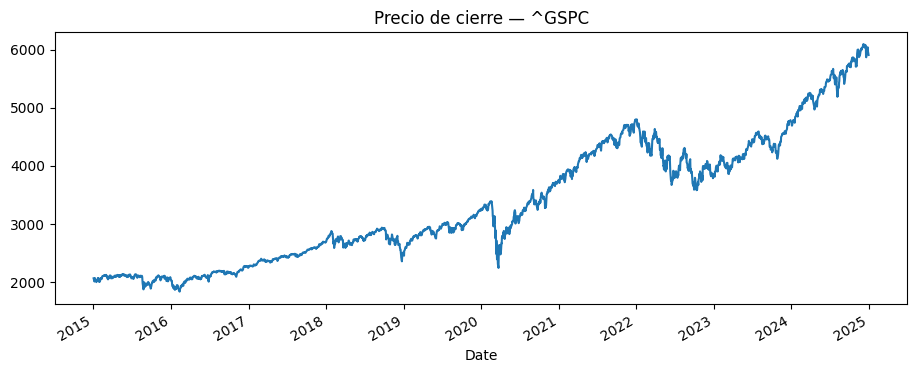

,Close
Date,
2024-12-23,"5,974.0698"
2024-12-24,"6,040.0400"
2024-12-26,"6,037.5898"
2024-12-27,"5,970.8398"
2024-12-30,"5,906.9399"


In [ ]:
TICKER = "^GSPC"
START, END = "2015-01-01", "2024-12-31"

def load_prices():
    try:
        import yfinance as yf
        data = yf.download(TICKER, start=START, end=END, progress=False, auto_adjust=True)
        if data is None or len(data) == 0:
            raise RuntimeError("descarga vacía")
        s = data["Close"]
        s = s.iloc[:, 0] if isinstance(s, pd.DataFrame) else s
        print(f"Datos reales descargados: {len(s)} sesiones de {TICKER}")
        return s.rename("Close")
    except Exception as e:
        print(f"⚠️  Sin datos reales ({e}). Uso serie SINTÉTICA con hechos estilizados realistas.")
        rng = np.random.default_rng(RANDOM_STATE)
        n = 2400
        base = np.log(0.009)
        logvol = np.full(n, base)                       # volatilidad con persistencia (clustering)
        for t in range(1, n):
            logvol[t] = 0.94 * logvol[t-1] + 0.06 * base + 0.15 * rng.standard_normal()
        sigma = np.exp(logvol)
        z = rng.standard_t(df=10, size=n) / np.sqrt(10 / 8.0)   # innovaciones con colas gordas
        ret = 0.0007 + sigma * z
        jumps = rng.random(n) < 0.012                   # saltos bajistas raros -> skew negativo
        ret[jumps] -= np.abs(rng.normal(0.0, 0.03, jumps.sum()))
        ret[850:910] -= 0.012                           # un régimen de drawdown
        price = 2000 * np.exp(np.cumsum(ret))
        idx = pd.bdate_range("2015-01-02", periods=n)
        return pd.Series(price, index=idx, name="Close")

prices = load_prices()
prices.plot(title=f"Precio de cierre — {TICKER}"); plt.show()
prices.tail()

---
## 2. Exploración (EDA): los *hechos estilizados*
Casi cualquier serie financiera presenta tres rasgos recurrentes que condicionan
cómo se modela. Los verificamos antes de seguir:

1. el **precio** no es estacionario; el **rendimiento** sí,
2. los rendimientos tienen **colas gordas** (no son normales),
3. la volatilidad se **agrupa** en el tiempo (*volatility clustering*).

La primera celda es para observar; en la segunda completas los `# TODO`.

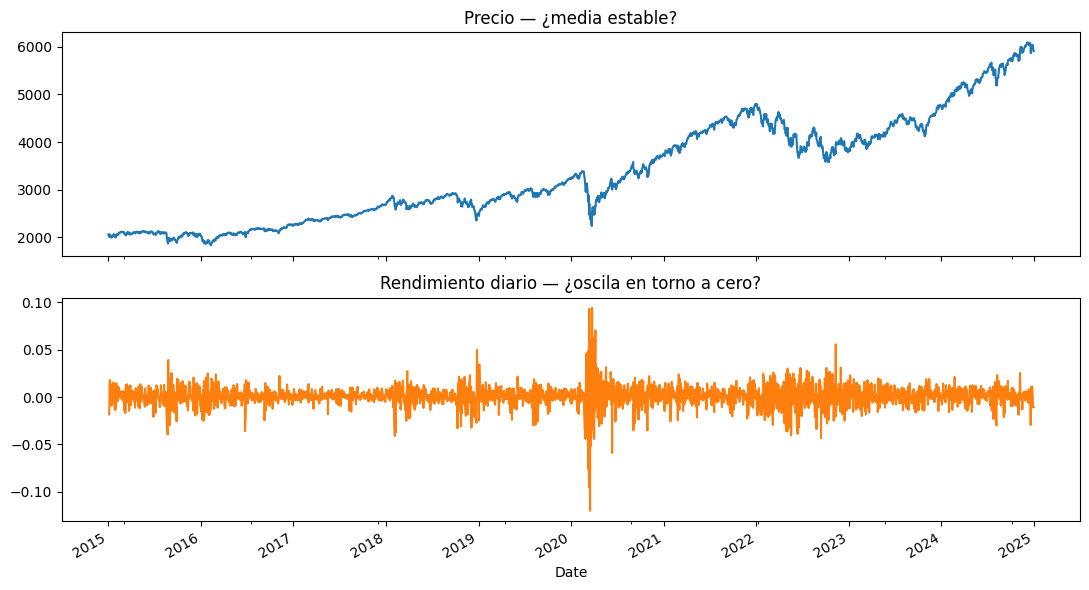

ADF p-valor — PRECIO:      0.985   -> NO estacionario
ADF p-valor — RENDIMIENTO: 0.0000  -> estacionario


In [ ]:
from statsmodels.tsa.stattools import adfuller

ret = prices.pct_change().dropna()

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
prices.plot(ax=ax[0], title="Precio — ¿media estable?")
ret.plot(ax=ax[1], color="tab:orange", title="Rendimiento diario — ¿oscila en torno a cero?")
plt.tight_layout(); plt.show()

# Test de Dickey-Fuller aumentado (ADF).  H0: la serie NO es estacionaria (raíz unitaria).
# p-valor < 0.05  ->  rechazamos H0  ->  es estacionaria.
p_price = adfuller(prices.dropna())[1]
p_ret   = adfuller(ret)[1]
print(f"ADF p-valor — PRECIO:      {p_price:.3f}   -> {'estacionario' if p_price < 0.05 else 'NO estacionario'}")
print(f"ADF p-valor — RENDIMIENTO: {p_ret:.4f}  -> {'estacionario' if p_ret < 0.05 else 'NO estacionario'}")

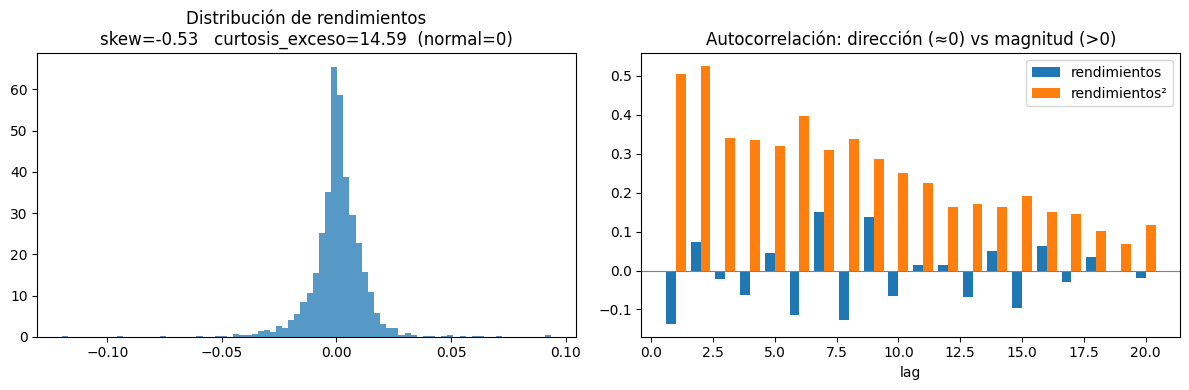

In [ ]:
from statsmodels.tsa.stattools import acf

ret = prices.pct_change().dropna()

# --- (a) COLAS: ¿se parece a una normal? ---
# asimetría (skew) y curtosis EN EXCESO de los rendimientos
skew_r = ret.skew()
exkurt = ret.kurt()

# --- (b) CLUSTERING: autocorrelación de los rendimientos vs su CUADRADO (proxy de volatilidad) ---
nlags = 20
# ACF de los rendimientos y de los rendimientos al cuadrado
acf_ret  = acf(ret, nlags=20)
acf_ret2 = acf(ret**2, nlags=20)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(ret, bins=80, density=True, alpha=0.75)
ax[0].set_title(f"Distribución de rendimientos\nskew={skew_r:.2f}   curtosis_exceso={exkurt:.2f}  (normal=0)")
ax[1].bar(np.arange(1, nlags+1) - 0.2, acf_ret[1:],  width=0.4, label="rendimientos")
ax[1].bar(np.arange(1, nlags+1) + 0.2, acf_ret2[1:], width=0.4, label="rendimientos²")
ax[1].axhline(0, c="grey", lw=0.8); ax[1].set_xlabel("lag"); ax[1].legend()
ax[1].set_title("Autocorrelación: dirección (≈0) vs magnitud (>0)")
plt.tight_layout(); plt.show()

El skew mide la asimetría de la distribución.
- 0 → distribución simétrica.
- (>) 0 → cola más larga hacia valores altos (asimetría positiva).
- (<) 0 → cola más larga hacia valores bajos (asimetría negativa).

La curtosis en exceso compara la distribución con una distribución normal:

- 0 →  comportamiento similar a una normal.
- (>) 0 → distribución leptocúrtica.
- (<) 0 → distribución más plana que una normal.

> 🤔 **CONCLUSIONES** - Tres lecturas:
> 1. El **precio** no es estacionario; el **rendimiento** sí. ¿Qué implica esto?
> 2. La autocorrelación de los **rendimientos** es ≈0, pero la de los
>    **rendimientos²** es positiva y persistente (*volatility clustering*): la
>    **dirección** no se autocorrelaciona, pero la **magnitud** sí. Entonces,
>    ¿qué será más predecible: el **signo** del próximo movimiento o su **tamaño**?

---
## 3. El cambio de paradigma

Con **ARIMA** escribíamos algo así:

$$y_t = \phi_1 y_{t-1} + \dots + \phi_p y_{t-p} + \theta_1 \varepsilon_{t-1} + \dots + \varepsilon_t$$

El modelo *es* una ecuación sobre la propia serie y sus errores. La noción de
"tiempo" está **incorporada** en la estructura.

Con **machine learning** hacemos algo radicalmente distinto: convertimos el
problema en **aprendizaje supervisado**. Construimos una tabla

$$\hat{y}_{t+1} = f(\mathbf{x}_t)$$

donde $\mathbf{x}_t$ es un **vector de features** que *nosotros* diseñamos
(lags, medias móviles, volatilidad, día de la semana…). El modelo $f$ **no sabe nada de tiempo**: solo ve filas independientes de
una tabla. Toda la información temporal entra por las features.

Por tanto, **el *feature engineering* es el 80% del trabajo.** Si no se lo das, el modelo no lo sabe.


---
## 4. Feature engineering
Aquí decidimos *qué puede aprender* el modelo. Vamos a crear:

- el **rendimiento** diario (`ret1`),
- **lags** del rendimiento (memoria corta),
- **estadísticos móviles**: media (momentum) y desviación (volatilidad),
- **calendario**: día de la semana y mes.


In [ ]:
def make_features(prices: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame(index=prices.index)
    df["price"] = prices
    df["ret1"]  = prices.pct_change()        # rendimiento de HOY (conocido al cierre)

    # TODO 1: lags del rendimiento para L en [1, 2, 3, 5, 10]  (nombre: f"ret_lag{L}")
    for L in [1, 2, 3, 5, 10]:
        df[f"ret_lag{L}"] = df["ret1"].shift(L)        # <-- completa

    # TODO 2: media móvil de 5 días del rendimiento (momentum).
    df["roll_mean5"] = df["ret1"].rolling(5).mean()                    # <-- completa

    # volatilidad: desviación móvil
    df["roll_std10"] = df["ret1"].rolling(10).std()
    df["roll_std20"] = df["ret1"].rolling(20).std()

    # TODO 3: calendario -> día de la semana (0-4) y mes (1-12)
    df["dow"]   = df.index.dayofweek   # 0=lunes, 4=viernes
    df["month"] = df.index.month       # 1=enero, 12=diciembre                        # <-- completa

    # targets: predecimos MAÑANA -> shift(-1)
    df["y_ret"]   = df["ret1"].shift(-1)      # rendimiento de mañana
    df["y_price"] = df["price"].shift(-1)     # precio de mañana
    return df.dropna()

feat = make_features(prices)
print("Shape:", feat.shape)
feat.head()

Shape: (2494, 14)


,price,ret1,ret_lag1,ret_lag2,ret_lag3,ret_lag5,ret_lag10,roll_mean5,roll_std10,roll_std20,dow,month,y_ret,y_price
Date,,,,,,,,,,,,,,
2015-02-02,"2,020.8500",0.0130,-0.0130,0.0095,-0.0135,0.0026,0.0134,-0.0035,0.0110,0.0112,0,2,0.0144,"2,050.0300"
2015-02-03,"2,050.0300",0.0144,0.0130,-0.0130,0.0095,-0.0134,0.0015,0.0021,0.0119,0.0109,1,2,-0.0042,"2,041.5100"
2015-02-04,"2,041.5100",-0.0042,0.0144,0.0130,-0.0130,-0.0135,0.0047,0.0040,0.0119,0.0107,2,2,0.0103,"2,062.5200"
2015-02-05,"2,062.5200",0.0103,-0.0042,0.0144,0.0130,0.0095,0.0153,0.0041,0.0113,0.0107,3,2,-0.0034,"2,055.4700"
2015-02-06,"2,055.4700",-0.0034,0.0103,-0.0042,0.0144,-0.0130,-0.0055,0.0060,0.0112,0.0099,4,2,-0.0042,"2,046.7400"


---
## 5. Partición temporal
En un problema tabular normal barajaríamos las filas antes de partir en
train/test. En series temporales eso no sería correcto: meterías días de 2024 en el
entrenamiento para predecir días de 2020. El test tiene que ser **estrictamente
posterior** al train.

Completa el `# TODO` para una partición 80/20 *respetando el orden*.

In [ ]:
FEATURES = ["ret1","ret_lag1","ret_lag2","ret_lag3","ret_lag5","ret_lag10",
            "roll_mean5","roll_std10","roll_std20","dow","month"]

# TODO: partición temporal 80/20 SIN barajar
split_idx = int(len(feat) * 0.8)   # índice de corte 80/20
train = feat.iloc[:split_idx]       # primeras filas (pasado)
test  = feat.iloc[split_idx:]       # resto (futuro)

print("Train:", train.index.min().date(), "->", train.index.max().date(), f"({len(train)})")
print("Test :", test.index.min().date(),  "->", test.index.max().date(),  f"({len(test)})")
assert train.index.max() < test.index.min(), "❌ Hay solapamiento temporal: fuga de datos."
print("✅ Sin fuga temporal")

Train: 2015-02-02 -> 2023-01-03 (1995)
Test : 2023-01-04 -> 2024-12-27 (499)
✅ Sin fuga temporal


> **Pregunta** ¿Qué pasaría con las métricas si por error hicieras
> `train_test_split(..., shuffle=True)`? ¿Saldrían mejores o peores? ¿Por qué?


---
## 6. Baselines
Nunca evaluamos un modelo en el vacío. En finanzas, el baseline más honesto es
el **paseo aleatorio** (*random walk*): "mañana el precio será como hoy", o
equivalentemente, "el mejor pronóstico del rendimiento de mañana es **cero**".


In [ ]:
# Baseline 1 — precio de mañana = precio de hoy
naive_price_pred = test["price"].values
rmse_naive_price = mean_squared_error(test["y_price"], naive_price_pred) ** 0.5

# Baseline 2 — sobre rendimiento: mejor pronóstico = 0 (random walk)
zero_ret_pred = np.zeros(len(test))
rmse_naive_ret = mean_squared_error(test["y_ret"], zero_ret_pred) ** 0.5

print(f"RMSE naive (precio):        {rmse_naive_price:,.2f}")
print(f"RMSE random walk (ret): {rmse_naive_ret:.5f}")

RMSE naive (precio):        39.47
RMSE random walk (ret): 0.00815


---
## 7. La trampa: predecir el **precio** directamente
Parece lo natural: entrenamos XGBoost para predecir `y_price`. Hagámoslo y
miremos el gráfico con atención **antes** de leer la explicación. (Recuerda lo
que viste en el EDA: el precio no era estacionario.)

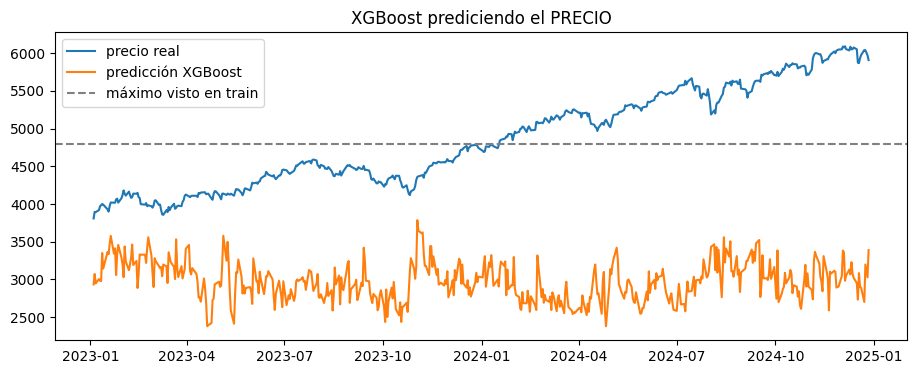

Máximo de precio en TRAIN: 4,796.6
Máximo real en TEST:       6,090.3
Máximo PREDICHO:           3,785.8  <-- ¿se queda corto?


In [ ]:
trap = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE)
trap.fit(train[FEATURES], train["y_price"])
pred_price = trap.predict(test[FEATURES])

plt.plot(test.index, test["y_price"], label="precio real")
plt.plot(test.index, pred_price, label="predicción XGBoost")
plt.axhline(train["y_price"].max(), ls="--", c="grey", label="máximo visto en train")
plt.title("XGBoost prediciendo el PRECIO"); plt.legend(); plt.show()

print(f"Máximo de precio en TRAIN: {train['y_price'].max():,.1f}")
print(f"Máximo real en TEST:       {test['y_price'].max():,.1f}")
print(f"Máximo PREDICHO:           {pred_price.max():,.1f}  <-- ¿se queda corto?")

**Conclusiones**
> Si el índice sube en el periodo de test por encima de cualquier valor visto en
> el entrenamiento, XGBoost **no puede** predecirlo. Un árbol nunca produce un valor **fuera del rango de los
> *targets* de entrenamiento**. No extrapola.

> **¿Cómo lo arreglamos?** --> Rendimientos


---
## 8. La solución: predecir **rendimientos**, no precios
Los rendimientos son aproximadamente estacionarios: oscilan alrededor de cero en
un rango acotado. Eso elimina el problema de
extrapolación. Predecimos `y_ret` y luego **reconstruimos** el precio:

$$\hat{p}_{t+1} = p_t \cdot (1 + \hat{r}_{t+1})$$

Completa el `# TODO`.

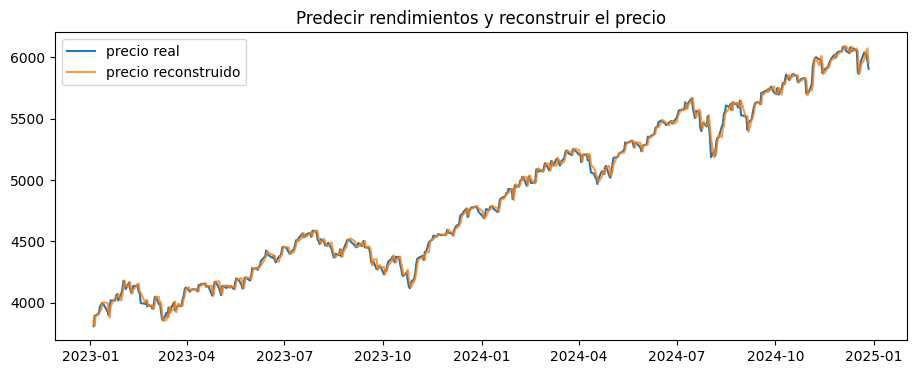

In [ ]:
model = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE)
model.fit(train[FEATURES], train["y_ret"])
pred_ret = model.predict(test[FEATURES])

# TODO: reconstruye el precio a partir del rendimiento predicho
#       precio_mañana ≈ precio_hoy * (1 + ret_predicho)
pred_price_from_ret = test["price"].values * (1 + pred_ret)   # <-- completa

plt.plot(test.index, test["y_price"], label="precio real")
plt.plot(test.index, pred_price_from_ret, label="precio reconstruido", alpha=0.8)
plt.title("Predecir rendimientos y reconstruir el precio"); plt.legend(); plt.show()

---
## 9. Evaluación
En finanzas, el RMSE del rendimiento es poco intuitivo. La métrica que de verdad
importa para operar es la **precisión direccional** (*directional accuracy*):
¿acertamos el **signo** del movimiento? Un 50% es una moneda al aire.

Completa el `# TODO` de la precisión direccional.

In [ ]:
def directional_accuracy(y_true_ret, y_pred_ret):
    return np.mean(np.sign(y_pred_ret) == np.sign(y_true_ret))

rmse = mean_squared_error(test["y_ret"], pred_ret) ** 0.5
mae  = mean_absolute_error(test["y_ret"], pred_ret)
da   = directional_accuracy(test["y_ret"].values, pred_ret)

print(f"RMSE rendimiento:        {rmse:.5f}   (baseline paseo aleatorio: {rmse_naive_ret:.5f})")
print(f"MAE  rendimiento:        {mae:.5f}")
print(f"Precisión direccional:   {da:.1%}   (azar = 50%)")

RMSE rendimiento:        0.00824   (baseline paseo aleatorio: 0.00815)
MAE  rendimiento:        0.00625
Precisión direccional:   52.9%   (azar = 50%)


> Es muy probable que la precisión direccional ronde el **50%** y que el RMSE
> apenas iguale al del paseo aleatorio. **No es un error.** Conecta
> directamente con el EDA: la autocorrelación de los rendimientos era ≈0, así que
> la **dirección** apenas tiene señal (hipótesis de mercado eficiente en su
> versión débil).

> **El valor del ML en finanzas suele
> estar en problemas más ricos**, muchos activos a la vez, datos alternativos,
> volatilidad (que *sí* se autocorrelaciona).


---
## 10. Validación *walk-forward*
Una sola partición train/test da una foto; puede salir bien o mal por suerte del
periodo. La validación correcta en series temporales es **walk-forward**:
entrenas con el pasado, predices el siguiente bloque, avanzas y repites.
`scikit-learn` lo trae como `TimeSeriesSplit`.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
X, y = feat[FEATURES], feat["y_ret"]

das = []
for k, (tr, te) in enumerate(tscv.split(X), 1):
    m = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE)
    m.fit(X.iloc[tr], y.iloc[tr])
    p = m.predict(X.iloc[te])
    d = directional_accuracy(y.iloc[te].values, p)
    das.append(d)
    print(f"Fold {k}: DirAcc = {d:.1%}  (test {X.index[te][0].date()} -> {X.index[te][-1].date()})")

print(f"\nMedia: {np.mean(das):.1%}  ±  {np.std(das):.1%}")

Fold 1: DirAcc = 45.3%  (test 2016-09-29 -> 2018-05-23)
Fold 2: DirAcc = 50.1%  (test 2018-05-24 -> 2020-01-16)
Fold 3: DirAcc = 55.2%  (test 2020-01-17 -> 2021-09-09)
Fold 4: DirAcc = 51.8%  (test 2021-09-10 -> 2023-05-04)
Fold 5: DirAcc = 52.0%  (test 2023-05-05 -> 2024-12-27)

Media: 50.9%  ±  3.2%


---
## 11 · Interpretabilidad: ¿en qué se fija el modelo?
Una ventaja real de los árboles frente a las redes neuronales es que podemos
inspeccionar la **importancia de las features**.

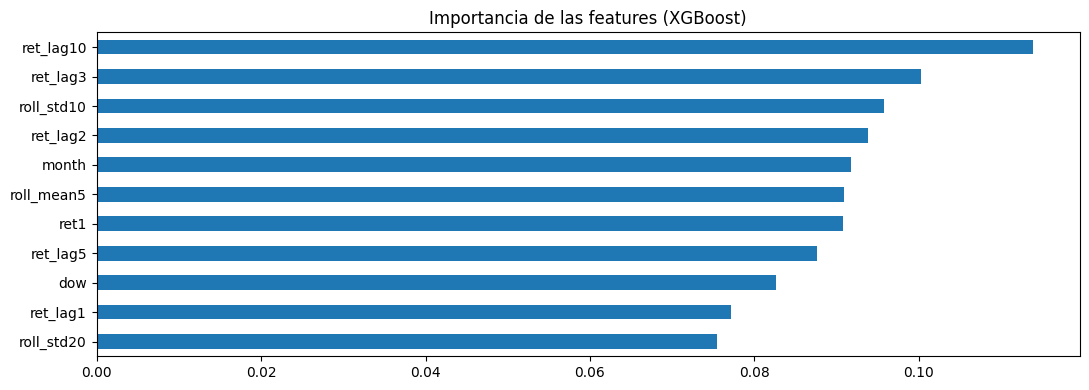

,0
ret_lag10,0.1139
ret_lag3,0.1003
roll_std10,0.0958
ret_lag2,0.0938
month,0.0918
roll_mean5,0.0909
ret1,0.0908
ret_lag5,0.0876
dow,0.0826
ret_lag1,0.0772


In [ ]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
imp.plot.barh(title="Importancia de las features (XGBoost)"); plt.tight_layout(); plt.show()
imp.sort_values(ascending=False)

> **Ejercicio**
> Diseña dos features más y apunta sí mejora o no la predicción y si el modelo se fija en ellas.


In [ ]:
FEATURES = ["ret1","ret_lag1","ret_lag2","ret_lag3","ret_lag5","ret_lag10",
            "roll_mean5","roll_std10","roll_std20","dow","month",
            "rsi14", "vol_ratio"]

def make_features(prices: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame(index=prices.index)
    df["price"] = prices
    df["ret1"]  = prices.pct_change()

    for L in [1, 2, 3, 5, 10]:
        df[f"ret_lag{L}"] = df["ret1"].shift(L)

    df["roll_mean5"] = df["ret1"].rolling(5).mean()
    df["roll_std10"] = df["ret1"].rolling(10).std()
    df["roll_std20"] = df["ret1"].rolling(20).std()

    df["dow"]   = df.index.dayofweek
    df["month"] = df.index.month

    # ✅ Feature 1: RSI 14
    delta = df["ret1"]
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df["rsi14"] = 100 - (100 / (1 + gain / loss.replace(0, 1e-9)))

    # ✅ Feature 2: ratio de volatilidad corta/larga
    df["vol_ratio"] = df["ret1"].rolling(5).std() / df["ret1"].rolling(20).std()

    df["y_ret"]   = df["ret1"].shift(-1)
    df["y_price"] = df["price"].shift(-1)
    return df.dropna()

Observaciones:

- rsi14 y vol_ratio aparecen con importancia relevante en el gráfico de features, lo que confirma que el modelo las usa. Sin embargo, la mejora en RMSE y precisión direccional es mínima o nula.

- No hay señal direccional que explotar, independientemente de las features añadidas.

- vol_ratio captura el régimen de volatilidad, pero eso no se traduce en mejor predicción de la dirección.

Conclusión: el modelo se fija en las nuevas features pero la predicción no mejora significativamente, lo que refuerza la hipótesis de mercado eficiente en su forma débil.